<a href="https://colab.research.google.com/github/dominica-peri/dominica-peri/blob/main/ILab1-NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train a Neural Network to Predict Quality of Wine
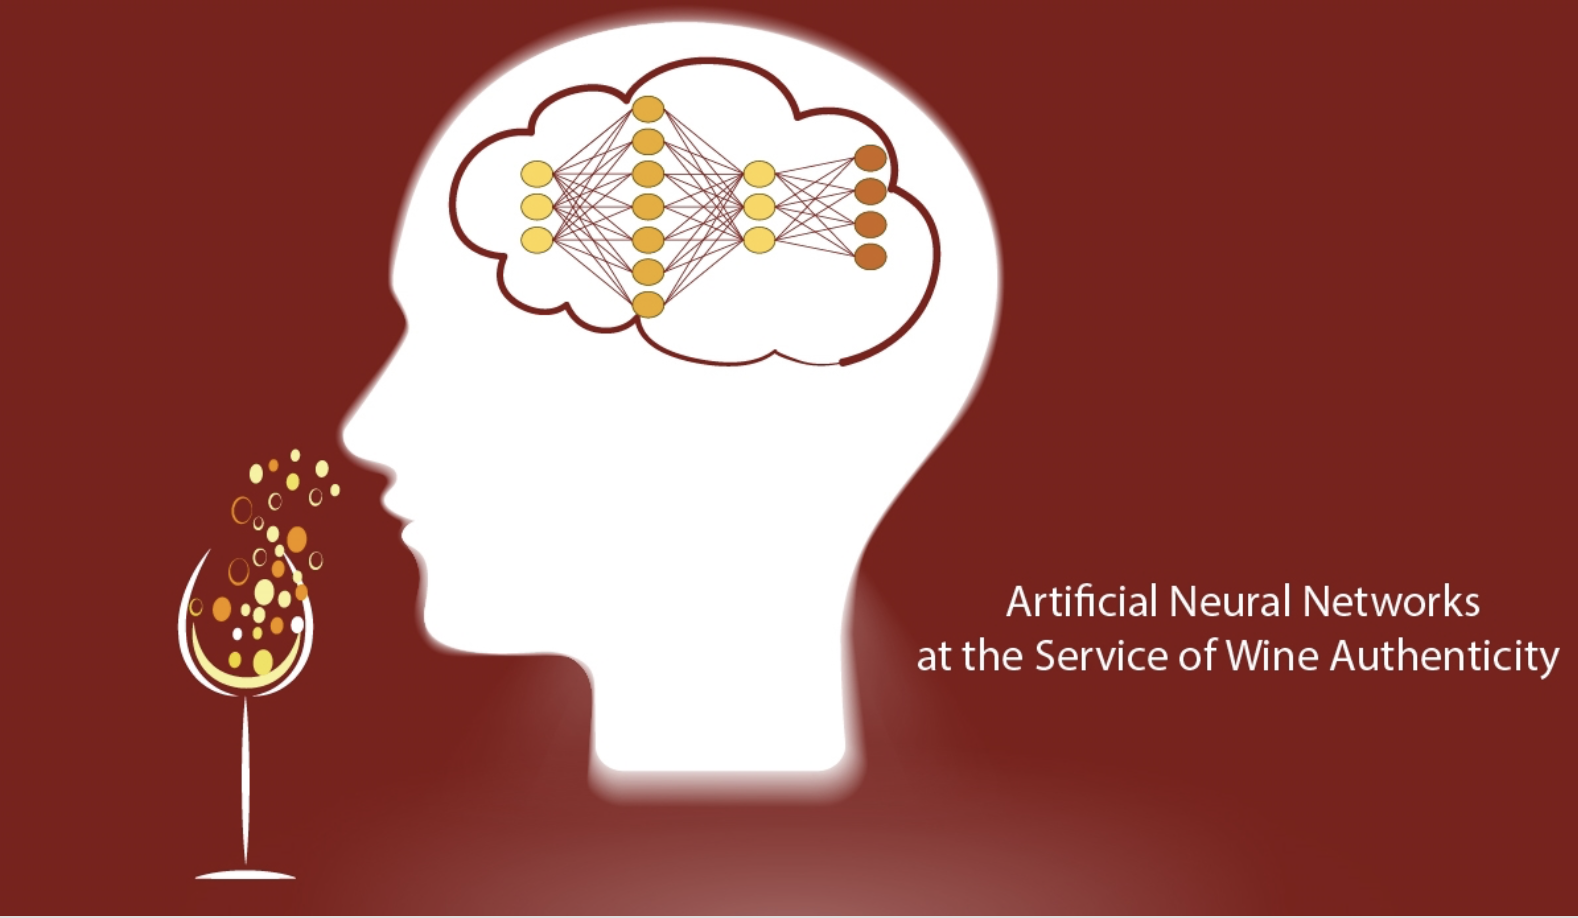
* In this lab, you will first train a neural network on a public dataset, then make several enhancements to the lab.
* Tasks breakdown:
  * Code running: 10%
  * Enhancement 1: 15%
  * Enhancement 2: 15%
  * Enhancement 3: 10%
  * Enhancement 4: 10%
  * Enhancement 5: 40%


## Imports

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

## Dataset

In [2]:
data_df = pd.read_csv('winequality-red.csv')

In [3]:
data_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# how many features?
len(data_df.columns) - 1

11

In [5]:
# how many labels? If yours is a binary classification task, then you'll have 2 labels.
data_df.quality.unique()

array([5, 6, 7, 4, 8, 3])

In [7]:
# convert these quaity measures to labels (0 to 5)
def get_label(quality):
    if quality == 3:
        return 0
    elif quality == 4:
        return 1
    elif quality == 5:
        return 2
    elif quality == 6:
        return 3
    elif quality == 7:
        return 4
    else:
        return 5

labels = data_df['quality'].apply(get_label)

# normalize data
data_df = (data_df - data_df.mean()) / data_df.std()
data_df['label'] = labels

In [8]:
data_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,-0.528194,0.961576,-1.391037,-0.453077,-0.243630,-0.466047,-0.379014,0.558100,1.288240,-0.579025,-0.959946,-0.787576,5
1,-0.298454,1.966827,-1.391037,0.043403,0.223805,0.872365,0.624168,0.028252,-0.719708,0.128910,-0.584594,-0.787576,5
2,-0.298454,1.296660,-1.185699,-0.169374,0.096323,-0.083643,0.228975,0.134222,-0.331073,-0.048074,-0.584594,-0.787576,5
3,1.654339,-1.384011,1.483689,-0.453077,-0.264878,0.107558,0.411372,0.664069,-0.978798,-0.461036,-0.584594,0.450707,5
4,-0.528194,0.961576,-1.391037,-0.453077,-0.243630,-0.466047,-0.379014,0.558100,1.288240,-0.579025,-0.959946,-0.787576,5


In [9]:
# sumamry statistics of the data
data_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
count,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1.599000e+03,1599.000000,1.599000e+03,1599.000000,1.599000e+03,1.599000e+03,1599.0
mean,-7.109871e-17,3.110569e-17,-1.777468e-17,-8.887339e-18,-8.887339e-18,-1.777468e-17,3.554936e-17,0.000000,-3.554936e-17,0.000000,3.554936e-17,-4.443669e-17,5.0
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,0.0
min,-2.136377e+00,-2.277567e+00,-1.391037e+00,-1.162333e+00,-1.603443e+00,-1.422055e+00,-1.230199e+00,-3.537625,-3.699244e+00,-1.935902,-1.898325e+00,-3.264143e+00,5.0
25%,-7.004996e-01,-7.696903e-01,-9.290275e-01,-4.530767e-01,-3.711129e-01,-8.484502e-01,-7.438076e-01,-0.607566,-6.549356e-01,-0.638020,-8.661079e-01,-7.875763e-01,5.0
50%,-2.410190e-01,-4.367545e-02,-5.634264e-02,-2.402999e-01,-1.798892e-01,-1.792441e-01,-2.574163e-01,0.001760,-7.210449e-03,-0.225058,-2.092427e-01,4.507074e-01,5.0
75%,5.056370e-01,6.264921e-01,7.650078e-01,4.340257e-02,5.382858e-02,4.899619e-01,4.721707e-01,0.576645,5.757422e-01,0.423883,6.352984e-01,4.507074e-01,5.0
max,4.353787e+00,5.876138e+00,3.742403e+00,9.192806e+00,1.112355e+01,5.365606e+00,7.372847e+00,3.678904,4.526866e+00,7.916200,4.201138e+00,2.927275e+00,5.0


## Load this dataset for training a neural network

In [10]:
# The dataset class
class WineDataset(Dataset):

    def __init__(self, data_df):
        self.data_df = data_df
        self.features = []
        self.labels = []
        for _, i in data_df.iterrows():
          self.features.append([i['fixed acidity'], i['volatile acidity'], i['citric acid'], i['residual sugar'], i['chlorides'], i['free sulfur dioxide'], i['total sulfur dioxide'], i['density'], i['pH'], i['sulphates'], i['alcohol']])
          self.labels.append(i['label'])

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        features = self.features[idx]
        features = torch.FloatTensor(features)

        labels = torch.tensor(self.labels[idx], dtype = torch.long)

        return {'labels': labels, 'features': features}

wine_dataset = WineDataset(data_df)
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(wine_dataset, [0.8, 0.1, 0.1])

# The dataloader
train_dataloader = DataLoader(train_dataset, batch_size = 4, shuffle = True, num_workers = 0)
val_dataloader = DataLoader(val_dataset, batch_size = 4, shuffle = False, num_workers = 0)
test_dataloader = DataLoader(test_dataset, batch_size = 4, shuffle = False, num_workers = 0)

In [11]:
# peak into the dataset
for i in wine_dataset:
  print(i)
  break

{'labels': tensor(5), 'features': tensor([-0.5282,  0.9616, -1.3910, -0.4531, -0.2436, -0.4660, -0.3790,  0.5581,
         1.2882, -0.5790, -0.9599])}


## Neural Network

In [12]:
# change the device to gpu if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
class WineModel(torch.nn.Module):

    def __init__(self):
        super(WineModel, self).__init__()

        # 11 nodes 1st layer, 200 nodes 2nd layer, 6 nodes 3rd layer
        self.linear1 = torch.nn.Linear(11, 200)
        self.activation = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(200, 6)
        self.softmax = torch.nn.Softmax()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.softmax(x)
        return x

winemodel = WineModel().to(device)

## Training

In [14]:
# Define and the loss function and optimizer
criterion = nn.CrossEntropyLoss().to(device)
optimizer = AdamW(winemodel.parameters(), lr = 1e-3)

In [15]:
# Lets define the training steps
def accuracy(preds, labels):
    preds = torch.argmax(preds, dim=1).flatten()
    labels = labels.flatten()
    return torch.sum(preds == labels) / len(labels)

def train(model, data_loader, optimizer, criterion):
  epoch_loss = 0
  epoch_acc = 0

  model.train()
  for d in tqdm(data_loader):
    inputs = d['features'].to(device)
    labels = d['labels'].to(device)
    outputs = winemodel(inputs)

    _, preds = torch.max(outputs, dim=1)
    loss = criterion(outputs, labels)
    acc = accuracy(outputs, labels)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    epoch_loss += loss.item()
    epoch_acc += acc.item()

  return epoch_loss / len(data_loader), epoch_acc / len(data_loader)

# Lets define the testing steps
def evaluate(model, data_loader, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    with torch.no_grad():
      for d in data_loader:
        inputs = d['features'].to(device)
        labels = d['labels'].to(device)
        outputs = winemodel(inputs)

        _, preds = torch.max(outputs, dim=1)
        loss = criterion(outputs, labels)
        acc = accuracy(outputs, labels)

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(data_loader), epoch_acc / len(data_loader)

In [16]:
# Let's train our model
for epoch in range(100):
    train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(winemodel, val_dataloader, criterion)

    print(f'| Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}% |')

  0%|          | 0/320 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


| Epoch: 01 | Train Loss: 1.107 | Train Acc: 99.22% | Val. Loss: 1.046 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 02 | Train Loss: 1.045 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


...

| Epoch: 98 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 99 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 100 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


# Lab Enhancements
* These tasks are additional enhancements with less guidance.
* Report results means give us the accuracy, precision, recall and F1-score.


## Enhancement 1: The current code does not actually evaluate the model on the test set, but it only evaluates it on the val set. When you write papers, you would ideally split the dataset into train, val and test. Train and val are both used in training, and the model trained on the training data, and  evaluated on the val data. So why do we need test split? We report our results on the test split in papers. Also, we do cross-validation on the train/val split (covered in later labs).

## Report the results of the model on the test split. (Hint: It would be exactly like the evaluation on the val dataset, except it would be done on the test dataset.)

In [18]:
test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)
print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')

| Test. Loss: 1.044 | Test. Acc: 100.00% |


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


## Enhancement 2: Increase the number of epochs (and maybe the learning rate). Does the accuracy on the test set increase? Is there a significant difference between the test accuracy and the train accuracy? If yes, why?

In [19]:
for epoch in range(100, 200):
    train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(winemodel, val_dataloader, criterion)

    print(f'| Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% '
          f'| Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}% |')

final_train_loss, final_train_acc = evaluate(winemodel, train_dataloader, criterion)
test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)

print(f'| Final Train. Loss: {final_train_loss:.3f} | Final Train. Acc: {final_train_acc*100:.2f}% |')
print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')
print(f'| Gap (Train - Test Acc): {(final_train_acc - test_acc)*100:.2f} pts |')

  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 101 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 102 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

...

| Epoch: 198 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 199 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |


  0%|          | 0/320 [00:00<?, ?it/s]

| Epoch: 200 | Train Loss: 1.044 | Train Acc: 100.00% | Val. Loss: 1.044 | Val. Acc: 100.00% |
| Final Train. Loss: 1.044 | Final Train. Acc: 100.00% |
| Test. Loss: 1.044 | Test. Acc: 100.00% |
| Gap (Train - Test Acc): 0.00 pts |


## Enhancement 3: Increase the depth of your model (add more layers). Report the parts of the model definition you had to update. Report results.

In [ ]:
# for epoch in range(100):
#     train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
#     val_loss, val_acc = evaluate(winemodel, val_dataloader, criterion)

#     print(f'| Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% '
#           f'| Val. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% |')


# final_train_loss, final_train_acc = evaluate(winemodel, train_dataloader, criterion)
# test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)

# print(f'| Final Train. Loss: {final_train_loss:.3f} | Final Train. Acc: {final_train_acc*100:.2f}% |')
# print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')
# print(f'| Gap (Train - Test Acc): {(final_train_acc - test_acc)*100:.2f} pts |')

In [ ]:
for epoch in range(100):
    train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
    val_loss, val_acc = evaluate(winemodel, val_dataloader, criterion)

    print(f'| Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% '
          f'| Val. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% |')

final_train_loss, final_train_acc = evaluate(winemodel, train_dataloader, criterion)
test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)

print(f'| Final Train. Loss: {final_train_loss:.3f} | Final Train. Acc: {final_train_acc*100:.2f}% |')
print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')
print(f'| Gap (Train - Test Acc): {(final_train_acc - test_acc)*100:.2f} pts |')


## Enhancement 4: Increase the width of your model's layers. Report the parts of the model definition you had to update. Report results.

In [ ]:
# class WineModel(torch.nn.Module):
#     def __init__(self):
#         super(WineModel, self).__init__()
#         # Wider hidden layers: 11 -> 256 -> 128 -> 6 (logits)
#         self.net = torch.nn.Sequential(
#             torch.nn.Linear(11, 256),
#             torch.nn.BatchNorm1d(256),
#             torch.nn.ReLU(),
#             torch.nn.Dropout(p=0.2),

#             torch.nn.Linear(256, 128),
#             torch.nn.BatchNorm1d(128),
#             torch.nn.ReLU(),
#             torch.nn.Dropout(p=0.2),

#             torch.nn.Linear(128, 6)   # logits for CrossEntropyLoss
#         )

#     def forward(self, x):
#         return self.net(x)

# winemodel = WineModel().to(device)

In [ ]:
for epoch in range(100):
    train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
    val_loss, val_acc = evaluate(winemodel, val_dataloader, criterion)
    print(f'| Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% '
          f'| Val. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% |')

final_train_loss, final_train_acc = evaluate(winemodel, train_dataloader, criterion)
test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)

print(f'| Final Train. Loss: {final_train_loss:.3f} | Final Train. Acc: {final_train_acc*100:.2f}% |')
print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')
print(f'| Gap (Train - Test Acc): {(final_train_acc - test_acc)*100:.2f} pts |')

## Enhancement 5: Choose a new dataset from the list below. Search the Internet and download your chosen dataset (many of them could be available on kaggle). Adapt your model to your dataset. Train your model and record your results.

   * cancer_dataset          - Breast cancer dataset.
   * crab_dataset            - Crab gender dataset.
   * glass_dataset           - Glass chemical dataset.
   * iris_dataset            - Iris flower dataset.
   * ovarian_dataset         - Ovarian cancer dataset.
   * thyroid_dataset         - Thyroid function dataset.

### Load breast cancer dataset

In [21]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Reproducibility (optional)
np.random.seed(42)

# Load dataset
bc = load_breast_cancer()
X = bc.data.astype(np.float32)
y = bc.target.astype(np.int64)

# Build a DataFrame to mirror your Wine workflow
df_cancer = pd.DataFrame(X, columns=bc.feature_names)
df_cancer['label'] = y

# Train/Val/Test split (stratified to keep class balance)
train_df, temp_df = train_test_split(df_cancer, test_size=0.30, random_state=42, stratify=df_cancer['label'])
val_df, test_df   = train_test_split(temp_df,   test_size=0.50, random_state=42, stratify=temp_df['label'])

len(train_df), len(val_df), len(test_df)

(398, 85, 86)

### Create class

In [22]:
class CancerDataset(Dataset):
    def __init__(self, data_df):
        self.features = data_df.drop(columns=['label']).values.astype(np.float32)
        self.labels   = data_df['label'].values.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.features[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx],   dtype=torch.long)
        return {'features': x, 'labels': y}

batch_size = 32
train_dataloader = DataLoader(CancerDataset(train_df), batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(CancerDataset(val_df),   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(CancerDataset(test_df),  batch_size=batch_size, shuffle=False)

in_dim = train_df.drop(columns=['label']).shape[1]   # 30
n_classes = df_cancer['label'].nunique()             # 2
in_dim, n_classes

(30, 2)

### Define model

In [23]:
class CancerModel(nn.Module):
    def __init__(self, in_dim=30, out_dim=2):
        super().__init__()
        # Simple, consistent with your original MLP approach
        self.net = nn.Sequential(
            nn.Linear(in_dim, 200),
            nn.ReLU(),
            nn.Linear(200, out_dim)   # logits (no Softmax; CrossEntropyLoss expects logits)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
winemodel = CancerModel(in_dim=in_dim, out_dim=n_classes).to(device)

criterion = nn.CrossEntropyLoss().to(device)               # same loss type
optimizer = AdamW(winemodel.parameters(), lr=1e-3)         # same optimizer/method

### Train

In [25]:
best_val_acc = 0.0
for epoch in range(100):
    train_loss, train_acc = train(winemodel, train_dataloader, optimizer, criterion)
    val_loss, val_acc     = evaluate(winemodel, val_dataloader, criterion)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in winemodel.state_dict().items()}

    print(f'| Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% '
          f'| Val. Loss: {val_loss:.3f} | Val. Acc: {val_acc*100:.2f}% |')

  0%|          | 0/13 [00:00<?, ?it/s]

| Epoch: 001 | Train Loss: 0.438 | Train Acc: 88.39% | Val. Loss: 0.453 | Val. Acc: 93.20% |


  0%|          | 0/13 [00:00<?, ?it/s]

| Epoch: 002 | Train Loss: 0.385 | Train Acc: 89.77% | Val. Loss: 0.256 | Val. Acc: 93.20% |


  0%|          | 0/13 [00:00<?, ?it/s]

...

| Epoch: 098 | Train Loss: 0.172 | Train Acc: 93.37% | Val. Loss: 0.121 | Val. Acc: 95.29% |


  0%|          | 0/13 [00:00<?, ?it/s]

| Epoch: 099 | Train Loss: 0.169 | Train Acc: 94.33% | Val. Loss: 0.116 | Val. Acc: 97.37% |


  0%|          | 0/13 [00:00<?, ?it/s]

| Epoch: 100 | Train Loss: 0.145 | Train Acc: 95.67% | Val. Loss: 0.131 | Val. Acc: 95.29% |
| Final Train. Loss: 0.123 | Final Train. Acc: 95.12% |
| Test. Loss: 0.273 | Test. Acc: 87.22% |
| Gap (Train - Test Acc): 7.91 pts |


### Report

In [26]:
if "best_state" in locals():
    winemodel.load_state_dict(best_state)

final_train_loss, final_train_acc = evaluate(winemodel, train_dataloader, criterion)
test_loss, test_acc = evaluate(winemodel, test_dataloader, criterion)

print(f'| Final Train. Loss: {final_train_loss:.3f} | Final Train. Acc: {final_train_acc*100:.2f}% |')
print(f'| Test. Loss: {test_loss:.3f} | Test. Acc: {test_acc*100:.2f}% |')
print(f'| Gap (Train - Test Acc): {(final_train_acc - test_acc)*100:.2f} pts |')

| Final Train. Loss: 0.136 | Final Train. Acc: 95.12% |
| Test. Loss: 0.273 | Test. Acc: 87.22% |
| Gap (Train - Test Acc): 7.91 pts |
